# 4.1 · Isolation Forest 이상 조기 탐지·우선순위

정상 fold Train으로 학습 → Train 전체 점수·정렬 → Validation 추론 → 개발 정상 전체로 최종 적합.
`if_score=-score_samples`이므로 클수록 이상합니다. 이 점수는 불량 확률이 아닙니다.
이 모듈은 시간적 선행 탐지 성능을 입증하지 않으며 검사 우선순위를 제공합니다.
경보 임계값·sample_weight는 임의로 설정하지 않습니다. 4.2~4.4에서 효과를 검증한 뒤 연결합니다.
운영 중 IF를 배치마다 다시 학습하지 않으며 최초 고정 버전을 자동 교체하지 않습니다.
[공식 IF API](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)


In [ ]:
from pathlib import Path
import json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/origin').is_dir())
_core_path = ROOT/'03.modeling/common/00_pipeline_core.ipynb'
for _cell in json.loads(_core_path.read_text(encoding='utf-8'))['cells']:
    if _cell['cell_type']=='code' and 'pipeline_library' in _cell.get('metadata',{}).get('tags',[]):
        exec(compile(''.join(_cell['source']), str(_core_path), 'exec'), globals())


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler



In [ ]:
def fit_if(normal, seed=42, n_estimators=300):
    variance = VarianceThreshold().fit(normal)
    values = variance.transform(normal)
    scaler = StandardScaler().fit(values)
    model = IsolationForest(n_estimators=n_estimators, max_samples='auto', contamination='auto',
                            random_state=seed, n_jobs=1).fit(scaler.transform(values))
    return dict(variance=variance, scaler=scaler, model=model, features=list(normal.columns))



In [ ]:
def score_if(bundle, x):
    if list(x.columns) != bundle['features'] or not np.isfinite(x.to_numpy(dtype=float)).all():
        raise ValueError('IF 입력 스키마/유한값 불일치')
    values = bundle['scaler'].transform(bundle['variance'].transform(x))
    return -bundle['model'].score_samples(values)  # 클수록 이상; 불량 확률 아님



In [ ]:
def rank_frame(ctx, bundle, x, ids, labels=None):
    if len(ids) != len(x) or len(set(ids)) != len(ids):
        raise ValueError('입력과 ID는 일대일이어야 합니다.')
    frame = ctx.validate_x(x).reset_index(drop=True).copy()
    frame.insert(0, 'record_id', list(ids))
    frame['input_position'] = np.arange(len(x))
    frame['if_score'] = score_if(bundle, x)
    if labels is not None:
        if len(labels) != len(x): raise ValueError('라벨 길이 불일치')
        frame['label'] = np.asarray(labels)
    frame = frame.sort_values(['if_score','input_position'], ascending=[False, True], kind='stable')
    frame['if_rank'] = np.arange(1,len(frame)+1)
    return frame.reset_index(drop=True)



In [ ]:
def train_isolation_forest(ctx, n_estimators=300):
    """각 fold 정상 train만 적합. train 전체 정렬과 validation 추론을 별도 저장."""
    if ctx.pointer()['fixed_if'] is not None:
        raise ValueError('IF 기준 버전이 이미 있습니다. 자동 재학습·교체하지 않습니다.')
    x, y, assignment, dev, test, manifest = ctx.data()
    out = ctx.output/'4.1_isolation_forest'/ctx.dataset
    out.mkdir(parents=True, exist_ok=True)
    oof, fold_records = [], []
    for fold in range(4):
        train = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.ne(fold), 'pattern_row'].to_numpy()
        valid = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.eq(fold), 'pattern_row'].to_numpy()
        normals = train[y.loc[train].eq(0)]
        assert not set(normals) & (set(valid)|set(test))
        bundle = fit_if(x.loc[normals], n_estimators=n_estimators)
        ordered = rank_frame(ctx,bundle,x.loc[train],assignment.loc[train,'pattern_id'],y.loc[train])
        ordered.to_csv(out/f'fold_{fold}_train_ranked.csv',index=False)
        validation = rank_frame(ctx,bundle,x.loc[valid],assignment.loc[valid,'pattern_id'],y.loc[valid])
        validation['fold'] = fold
        oof.append(validation)
        fold_records.append(dict(fold=fold, fit_pattern_rows=normals.tolist(),
                                 train_pattern_rows=train.tolist(), validation_pattern_rows=valid.tolist()))
    pd.concat(oof,ignore_index=True).to_csv(out/'validation_oof_scores.csv',index=False)
    final = fit_if(x.loc[dev][y.loc[dev].eq(0)], n_estimators=n_estimators)
    final.update(fit_pattern_rows=dev[y.loc[dev].eq(0)].tolist(), input_schema=ctx.features)
    ranked = rank_frame(ctx,final,x.loc[dev],assignment.loc[dev,'pattern_id'],y.loc[dev])
    ranked.to_csv(out/'development_ranked.csv',index=False)
    test_scores = rank_frame(ctx,final,x.loc[test],assignment.loc[test,'pattern_id'],y.loc[test])
    test_scores.to_csv(out/'test_followup_scores.csv',index=False)
    with ctx.lock():
        pointer = ctx.pointer()
        if pointer['fixed_if'] is not None:
            raise ValueError('IF 기준 버전이 이미 있습니다. 자동 교체하지 않습니다. 별도 검증·버전 변경이 필요합니다.')
        version = ctx.save_model('if', final, dict(status='fixed_scoring_reference',
            seed=42,n_estimators=n_estimators,fold_plan=fold_records,
            score_direction='higher_more_anomalous',label_probability=False,
            threshold=None, source_sha256=manifest['source_sha256']))
        pointer['fixed_if'] = version
        pointer['history'].append(dict(action='fix_if_reference',version=version,at=now_utc()))
        atomic_json(ctx.state/'registry.json',pointer)
    restored, _ = ctx.model(version,'if')
    np.testing.assert_array_equal(score_if(final,x.loc[test]),score_if(restored,x.loc[test]))
    atomic_json(out/'verification.json',dict(passed=True,version=version,fold_train_normal_only=True,
        no_test_fit=True,all_development_rows_scored=True,score_sign='-score_samples',
        automatic_threshold=False,test_used_for_selection=False,if_frozen_between_batches=True))
    return version


In [ ]:
def export_if_training_inputs(ctx, version):
    """고정 IF를 유지하며 fold별 학습 정렬 계약을 재생성·검증합니다."""
    final, manifest = ctx.model(version, 'if')
    x, y, assignment, dev, test, split = ctx.data()
    if manifest['source_sha256'] != split['source_sha256']:
        raise ValueError('IF 학습 원본이 변경됐습니다. 재검증이 필요합니다.')
    tables = {}
    for fold in range(4):
        train = assignment.loc[assignment.partition.eq('development') & assignment.cv_fold.ne(fold), 'pattern_row'].to_numpy()
        normal = train[y.loc[train].eq(0)]
        bundle = fit_if(x.loc[normal], seed=manifest['seed'], n_estimators=manifest['n_estimators'])
        tables[f'fold_{fold}_train_ranked.csv'] = rank_frame(ctx, bundle, x.loc[train], assignment.loc[train,'pattern_id'], y.loc[train])
    tables['development_ranked.csv'] = rank_frame(ctx, final, x.loc[dev], assignment.loc[dev,'pattern_id'], y.loc[dev])
    tables['test_scores.csv'] = rank_frame(ctx, final, x.loc[test], assignment.loc[test,'pattern_id'], y.loc[test])
    id_to_row = assignment.set_index('pattern_id').pattern_row
    with ctx.lock():
        folder = ctx.state/'if_inputs'/version
        folder.mkdir(parents=True, exist_ok=True)
        for name, frame in tables.items():
            frame.insert(1,'pattern_row',frame.record_id.map(id_to_row).astype(int))
            assert frame.if_score.is_monotonic_decreasing
            np.testing.assert_array_equal(frame[ctx.features].to_numpy(),x.loc[frame.pattern_row].to_numpy())
            np.testing.assert_array_equal(frame.label.to_numpy(),y.loc[frame.pattern_row].to_numpy())
            frame.to_csv(folder/name,index=False)
        contract = dict(dataset=ctx.dataset,if_version=version,
            if_artifact_sha256=manifest['artifact_sha256'],source_sha256=split['source_sha256'],
            split_sha256=sha256(ctx.root/f'data/processed/{ctx.dataset}/conservative/splits/split_assignments.csv'),
            files={name:sha256(folder/name) for name in tables},
            order='if_score descending; input_position ascending for ties',
            fold_if_fit='fold train normals only',created_at=now_utc())
        atomic_json(folder/'manifest.json',contract)
    return folder


## 실행 설정

아래 셀의 설정을 지정하고 실행합니다.

In [ ]:
DATASET = 'cn7'  # cn7 / rg3
pipeline = Pipeline(ROOT, DATASET)
if pipeline.pointer()['fixed_if']:
    print('고정 IF 유지:', pipeline.pointer()['fixed_if'])
else:
    print('IF 등록:', train_isolation_forest(pipeline))

if_inputs = export_if_training_inputs(pipeline, pipeline.pointer()['fixed_if'])
print('OCSVM 후속 입력 준비:', if_inputs)


## 결과보고서 v4 시각화

아래 셀만 실행하면 이 노트북에 해당하는 보고서 그림을 표시한다. 기존 학습·전처리·운영 셀을 다시 실행할 필요가 없다.
공통 생성 코드는 `reporting/visualizations.py`에 있다. 그림이 없으면 해당 코드를 먼저 실행한다.
고정 Test는 이미 관찰한 후속 평가이며, RF 연구 v1과 표준화 수정 후 v2를 구분한다.
시각화용 중앙값·IQR 변환은 표시 목적에 한정되며 모델 입력이나 기존 표준화 로직을 변경하지 않는다.


### IF 저장 모델의 Test 이상 점수

고유 패턴 CN7 N122·위험3 / RG3 N119·위험5 / if-a7a2fcba54e54d58 ; if-7e69cab8fdd04a17

IF는 이상 순위이며 불량 분류 임계값이 없다.

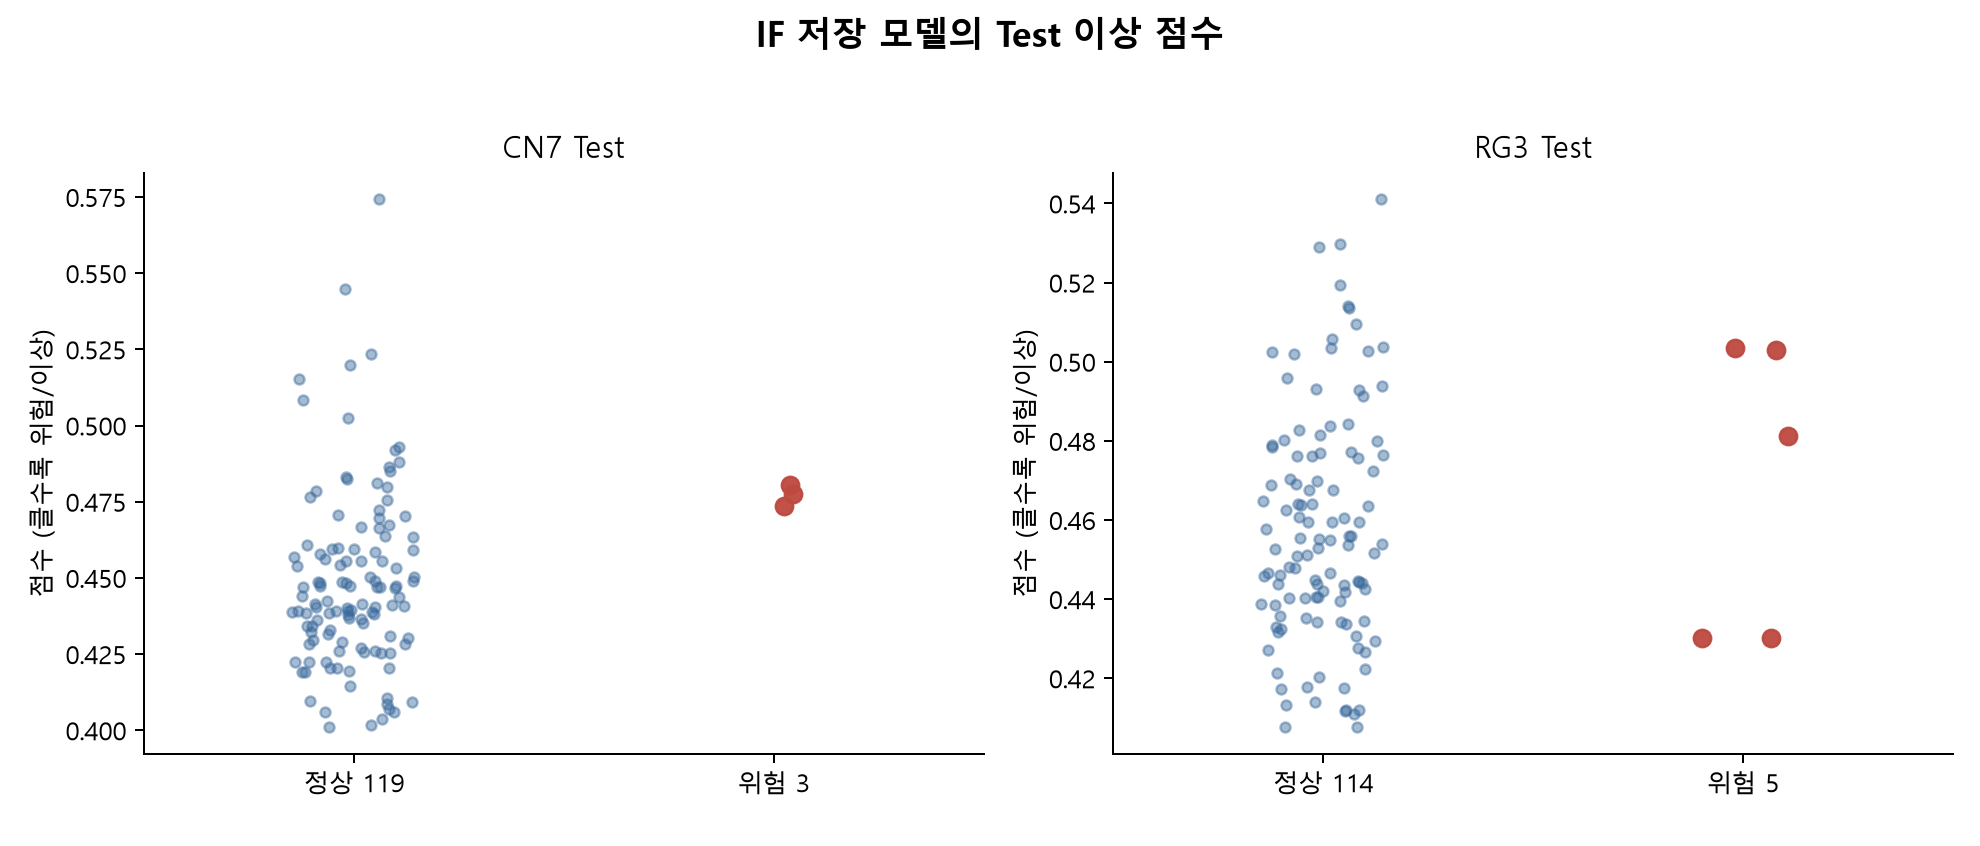

### 같은 검사 예산에서 저장 모델의 위험 발견 수

고정 패턴 Test CN7 N122·위험3 / RG3 N119·위험5 / exact_k / 5–50% / 임계값 분류와 별도

CN7의 10% 검사량에서는 고정 RF가 3개, LR이 2개를 포함하였다. RG3에서는 IF가 2개를 포함하였다. 소표본의 후속 결과이며 현장 효과로 확정하지 않았다.

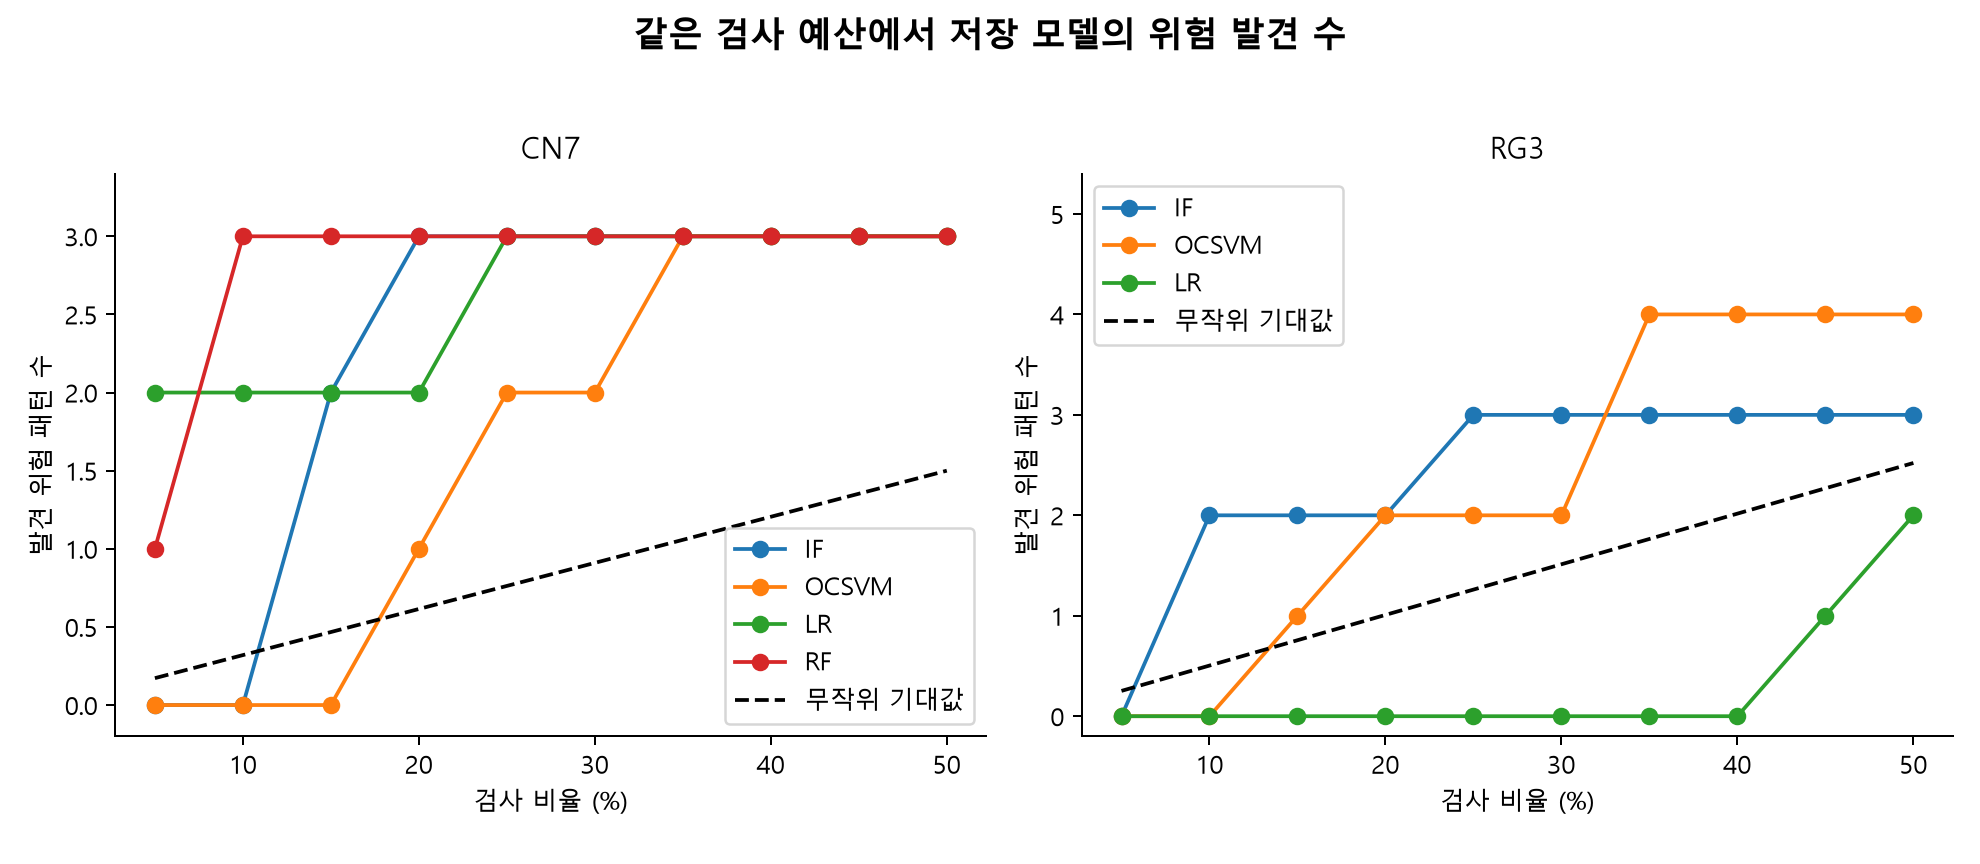

보고서 수록 그림: if_scores, model_budget_curves


In [6]:
# 보고서용 시각화: 기존 학습 셀을 실행하지 않고 저장 결과를 표시한다.
from pathlib import Path
import sys
_report_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "reporting/visualizations.py").is_file())
if str(_report_root) not in sys.path:
    sys.path.insert(0, str(_report_root))
from reporting.visualizations import show_notebook
_report_figure_ids = show_notebook('03.modeling/models/04.1_isolation_forest.ipynb')
print("보고서 수록 그림:", ", ".join(_report_figure_ids))
